# Vertex AI Generative Pipeline



## Dataset

Download the receipt dataset from ExpressExpesne https://expressexpense.com/blog/free-receipt-images-ocr-machine-learning-dataset/

In [ ]:
import requests
import zipfile
import os

url = "https://expressexpense.com/large-receipt-image-dataset-SRD.zip"
zip_path = "/content/receipt_dataset.zip"
extract_path = "/content/receipt_images"

# Download the file
print(f"Downloading {url}...")
response = requests.get(url, stream=True)
with open(zip_path, 'wb') as f:
    for chunk in response.iter_content(chunk_size=8192):
        f.write(chunk)

# Unzip the file
print("Unzipping...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Download and extraction complete.")

Unzipping...
Download and extraction complete.


Write the files to my storage bucket.

In [ ]:
from google.cloud import storage
import os
from concurrent.futures import ThreadPoolExecutor

# Configuration
project_id = 'jkwng-vertex-playground'
bucket_name = 'jkwng-vertex-experiments'
source_folder = '/content/receipt_images'
destination_prefix = 'receipt_images'

# Initialize Client
storage_client = storage.Client(project=project_id)
bucket = storage_client.bucket(bucket_name)

def upload_to_gcs(args):
    local_file, blob_name = args
    blob = bucket.blob(blob_name)
    blob.upload_from_filename(local_file)
    # print(f"Uploaded {blob_name}") # Uncomment for verbose output

# Prepare list of files to upload
files_to_upload = []
print(f"Preparing to upload files from {source_folder}...")

for root, dirs, files in os.walk(source_folder):
    for file in files:
        local_path = os.path.join(root, file)
        # Create relative path for the blob name
        relative_path = os.path.relpath(local_path, source_folder)
        blob_path = os.path.join(destination_prefix, relative_path)
        files_to_upload.append((local_path, blob_path))

print(f"Uploading {len(files_to_upload)} files to gs://{bucket_name}/{destination_prefix}...")

# Use ThreadPoolExecutor for parallel uploads
with ThreadPoolExecutor(max_workers=10) as executor:
    executor.map(upload_to_gcs, files_to_upload)

print("Upload complete.")

/usr/local/lib/python3.10/dist-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Preparing to upload files from /content/receipt_images...
Uploading 200 files to gs://jkwng-vertex-experiments/receipt_images...
Upload complete.


Let's view one of the images.

Found receipt_images/1000-receipt.jpg in GCS.
Displaying image from memory:


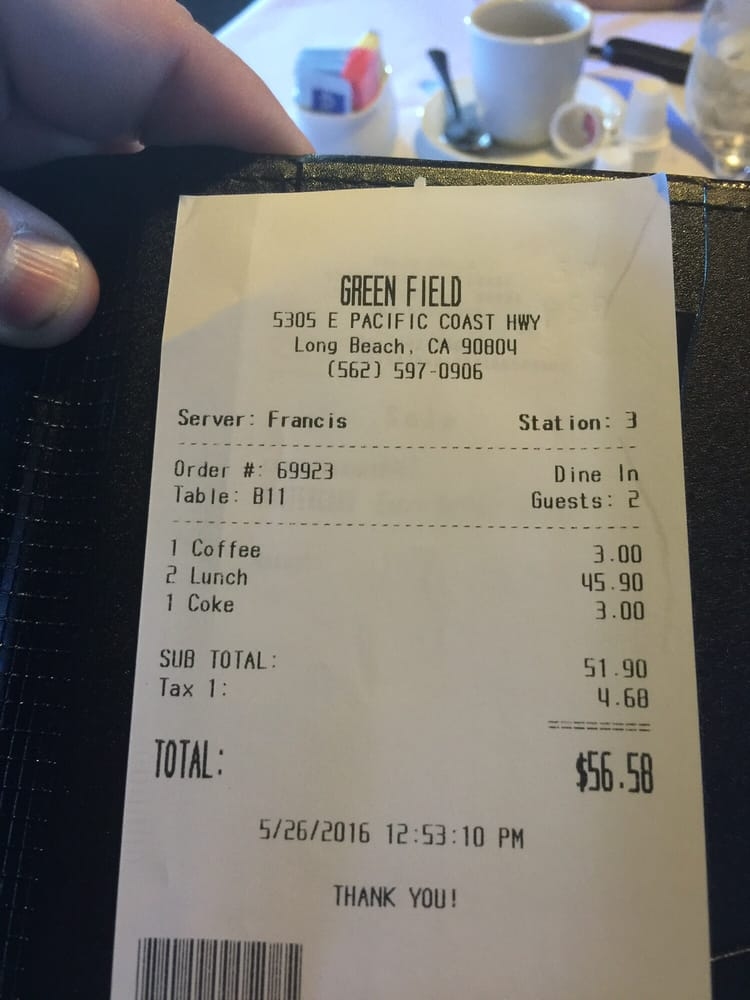

Image URI: gs://jkwng-vertex-experiments/receipt_images/1000-receipt.jpg


In [ ]:
from IPython.display import Image, display

# Find the first file in the bucket prefix
blobs = bucket.list_blobs(prefix=destination_prefix)
target_blob = None

for blob in blobs:
    if not blob.name.endswith('/'):  # Skip directory markers if any
        target_blob = blob
        break

if target_blob:
    print(f"Found {target_blob.name} in GCS.")

    # Download as bytes (in-memory) instead of to a file
    image_bytes = target_blob.download_as_bytes()

    print("Displaying image from memory:")
    display(Image(data=image_bytes))
else:
    print("No images found in the specified bucket location.")

image_uri = f"gs://{bucket_name}/{target_blob.name}"
print(f"Image URI: {image_uri}")

## Generative Task 1 : OCR text extraction

Build pydantic model to hold the contents of the receipt in json.

In [ ]:
from pydantic import BaseModel, Field
from typing import List

class ReceiptItem(BaseModel):
    quantity: int
    item_name: str
    price: float

class TaxItem(BaseModel):
    name: str
    amount: float

class ReceiptData(BaseModel):
    image_uri: str = Field(..., description="The URI of the receipt image")
    merchant_name: str
    date: str
    subtotal: float
    tax: List[TaxItem]
    total_amount: float
    items: List[ReceiptItem]

Use Gemini to populate the pydantic model with data from our sample image.

In [ ]:
from google import genai
from google.genai.types import HttpOptions, Part
from google.colab import userdata
from PIL import Image
import os

genai_client = genai.Client(vertexai=True, project=project_id, location="global")


Use the prompt to populate the pydantic model with the data in the image.  Note that Gemini hallucinates the file uri, that's OK, we'll just write it into the model afterward.

In [ ]:
from google.genai.types import GenerateContentConfig
model_id = "gemini-2.5-flash"

# Prompt
prompt = """
Extract the data from this receipt image.
"""

# Pass the GCS URI directly to the model
response = genai_client.models.generate_content(
    model=model_id,
    contents=[
        Part.from_uri(
            file_uri=image_uri,
            mime_type="image/jpeg",
        ),
        prompt
    ],
    config=GenerateContentConfig(
        response_json_schema=ReceiptData.model_json_schema(),
        response_mime_type="application/json",
    )
)

# Parse into Pydantic model
print("Gemini Response:")
print(response.text)

try:
    receipt_data = ReceiptData.model_validate_json(response.text)
    receipt_data.image_uri = image_uri
    print("\nSuccessfully populated Pydantic model:")
    display(receipt_data)
except Exception as e:
    print(f"\nError parsing into Pydantic model: {e}")

Gemini Response:
{
  "image_uri": "null",
  "merchant_name": "GREEN FIELD",
  "date": "5/26/2016",
  "subtotal": 51.90,
  "tax": [
    {
      "name": "Tax 1",
      "amount": 4.68
    }
  ],
  "total_amount": 56.58,
  "items": [
    {
      "quantity": 1,
      "item_name": "Coffee",
      "price": 3.00
    },
    {
      "quantity": 2,
      "item_name": "Lunch",
      "price": 45.90
    },
    {
      "quantity": 1,
      "item_name": "Coke",
      "price": 3.00
    }
  ]
}

Successfully populated Pydantic model:


ReceiptData(image_uri='gs://jkwng-vertex-experiments/receipt_images/1000-receipt.jpg', merchant_name='GREEN FIELD', date='5/26/2016', subtotal=51.9, tax=[TaxItem(name='Tax 1', amount=4.68)], total_amount=56.58, items=[ReceiptItem(quantity=1, item_name='Coffee', price=3.0), ReceiptItem(quantity=2, item_name='Lunch', price=45.9), ReceiptItem(quantity=1, item_name='Coke', price=3.0)])

## Generative Task 2: Line Item classification

Now we want to downstream classify each of the line items in the receipt to determine if it's a food item or a drink item. We will take the pydantic model and iterate through each of the items and ask the model to classify it as `FOOD`, `DRINK`, or `UNKNOWN`. We will extend the base models to enrich the line items with the category.

In [ ]:
from enum import Enum
from pydantic import TypeAdapter

class ItemCategory(str, Enum):
    FOOD = "FOOD"
    DRINK = "DRINK"
    UNKNOWN = "UNKNOWN"

class ReceiptItemWithCategory(ReceiptItem):
    category: ItemCategory = ItemCategory.UNKNOWN

class ReceiptDataWithCategories(ReceiptData):
    items: List[ReceiptItemWithCategory]

adapter = TypeAdapter(ItemCategory)
item_category_schema = adapter.json_schema()
print(f"category schema: {item_category_schema}")

receipt_data_with_categories = ReceiptDataWithCategories(**receipt_data.model_dump())

# reset this part, we're going to rebuild this list
receipt_data_with_categories.items = []

category schema: {'enum': ['FOOD', 'DRINK', 'UNKNOWN'], 'title': 'ItemCategory', 'type': 'string'}


Now for each line item, find its category and add it to the updated models

In [ ]:
for item in receipt_data.items:
  receipt_item_with_category = ReceiptItemWithCategory(**item.model_dump())
  classify_prompt = f"""
  Classify this item as food, drink, or unknown.
  Item: {item.item_name}
  """

  response = genai_client.models.generate_content(
    model=model_id,
    contents=[
        classify_prompt
    ],
    config=GenerateContentConfig(
        response_json_schema=item_category_schema,
        response_mime_type="application/json",
    )
  )
  receipt_item_with_category.category = response.text

  print(f"{receipt_item_with_category}")
  receipt_data_with_categories.items.append(receipt_item_with_category)

print(receipt_data_with_categories)

quantity=1 item_name='Coffee' price=3.0 category='"DRINK"'
quantity=2 item_name='Lunch' price=45.9 category='"FOOD"'
quantity=1 item_name='Coke' price=3.0 category='"DRINK"'
image_uri='gs://jkwng-vertex-experiments/receipt_images/1000-receipt.jpg' merchant_name='GREEN FIELD' date='5/26/2016' subtotal=51.9 tax=[TaxItem(name='Tax 1', amount=4.68)] total_amount=56.58 items=[ReceiptItemWithCategory(quantity=1, item_name='Coffee', price=3.0, category='"DRINK"'), ReceiptItemWithCategory(quantity=2, item_name='Lunch', price=45.9, category='"FOOD"'), ReceiptItemWithCategory(quantity=1, item_name='Coke', price=3.0, category='"DRINK"')]


## Task 3: Insert into BigQuery

Now I want to insert both the receipts and the line items into BigQuery so i can generate reports on receipt images, for example, determine how many drinks i am consuming as a proportion of my bill.

In [ ]:
from google.cloud import bigquery

from typing import List, Union, Any, get_origin, get_args
from pydantic import BaseModel, Field
from google.cloud import bigquery
import datetime

# Initialize BigQuery Client
bq_client = bigquery.Client(project=project_id)

# Define dataset and table
dataset_id = "receipt_analysis"
table_id = "receipt_items"





### Create the BQ Schema

In [ ]:
# convert the pydantic model to a bigquery schema
def pydantic_to_bq_schema(pydantic_model: type[BaseModel]) -> List[bigquery.SchemaField]:
    """
    Recursively converts a Pydantic model to a BigQuery SchemaField list.
    Handles nested models (RECORD) and lists (REPEATED).
    """
    schema = []

    for name, field_info in pydantic_model.model_fields.items():
        field_type = field_info.annotation
        mode = "REQUIRED" # Default to REQUIRED

        # Check if it allows None (Optional)
        # formatting check: is it Union[str, NoneType]?
        if get_origin(field_type) is Union and type(None) in get_args(field_type):
            mode = "NULLABLE"

        # Check if default value is None
        if field_info.default is None:
            mode = "NULLABLE"

        # 1. Handle Optionals (e.g., Optional[str]) to find the real type
        # (In BQ, almost everything should be NULLABLE anyway)
        origin = get_origin(field_type)
        if origin is  None:
             # Pure type (e.g. int, str)
             pass
        elif origin is type(None):
             # Use the other argument in Union[type, None]
             args = get_args(field_type)
             field_type = args[0]

        # 2. Handle Lists (BigQuery REPEATED mode)
        if get_origin(field_type) in (list, List):
            mode = "REPEATED"
            # Extract the inner type of the list (e.g., List[int] -> int)
            field_type = get_args(field_type)[0]

        # 3. Map Python Types to BigQuery Types
        bq_type = "STRING" # Default fallback
        sub_fields = ()

        if issubclass(field_type, str):
            bq_type = "STRING"
        elif issubclass(field_type, bool):
            bq_type = "BOOL"
        elif issubclass(field_type, int):
            bq_type = "INT64"
        elif issubclass(field_type, float):
            bq_type = "FLOAT64"
        elif issubclass(field_type, (datetime.datetime, datetime.date)):
            bq_type = "TIMESTAMP"
        elif issubclass(field_type, BaseModel):
            # --- RECURSION HAPPENS HERE ---
            bq_type = "RECORD"
            # Recursively get schema for the nested model
            sub_fields = pydantic_to_bq_schema(field_type)

        # 4. Create the SchemaField
        schema_field = bigquery.SchemaField(
            name=name,
            field_type=bq_type,
            mode=mode,
            description=field_info.description,
            fields=sub_fields # Only used if type is RECORD
        )
        schema.append(schema_field)

    return schema


In [ ]:
from google.api_core.exceptions import NotFound

# Create Dataset if it doesn't exist
dataset_ref = bq_client.dataset(dataset_id)
table_ref = dataset_ref.table(table_id)

try:
    bq_client.get_dataset(dataset_ref)
    print(f"Dataset {dataset_id} already exists.")
except NotFound:
    print(f"Creating dataset {dataset_id}...")
    dataset = bigquery.Dataset(dataset_ref)
    dataset.location = "US"
    bq_client.create_dataset(dataset)
    print(f"Dataset {dataset_id} created.")

# Define Schema dynamically from pydantic model
schema = pydantic_to_bq_schema(ReceiptDataWithCategories)

# Define Table and Constraints
table = bigquery.Table(table_ref, schema=schema)
table.table_constraints = bigquery.table.TableConstraints(
    primary_key=bigquery.table.PrimaryKey(columns=["image_uri"]),
    foreign_keys=[],
)

# Create or Update Table
try:
    existing_table = bq_client.get_table(table_ref)
    print(f"Table {table_id} already exists.")

    # Update constraints if they differ
    # Note: Updating PK on existing table requires the column to be NON-NULLABLE (REQUIRED)
    print("Updating table constraints...")
    existing_table.table_constraints = table.table_constraints
    bq_client.update_table(existing_table, ["table_constraints"])
    print(f"Table {table_id} updated with Primary Key.")

except NotFound:
    print(f"Creating table {table_id}...")
    bq_client.create_table(table)
    print(f"Table {table_id} created with Primary Key.")
except Exception as e:
    print(f"An error occurred: {e}")

Dataset receipt_analysis already exists.
Table receipt_items already exists.
Updating table constraints...
Table receipt_items updated with Primary Key.


### Load data
Convert the pydantic model and write it to bigquery using a load job.

In [ ]:
# 1. Prepare the data
# usage of mode='json' ensures Enums are converted to strings and dates to ISO format
rows_to_load = [receipt_data_with_categories.model_dump(mode='json')]

# 2. Configure the Load Job
job_config = bigquery.LoadJobConfig(
    # We can explicitly provide schema or let BQ detect it if the table exists
    schema=schema,
    write_disposition="WRITE_APPEND", # Append to existing table
)

# 3. Run the Load Job
print(f"Starting batch load of {len(rows_to_load)} rows to {dataset_id}.{table_id}...")

table_ref = f"{project_id}.{dataset_id}.{table_id}"
load_job = bq_client.load_table_from_json(
    rows_to_load,
    table_ref,
    job_config=job_config
)

# 4. Wait for the job to complete
load_job.result()

print(f"Batch load complete. Loaded {load_job.output_rows} rows.")

/usr/local/lib/python3.10/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `enum` - serialized value may not be as expected [field_name='category', input_value='"DRINK"', input_type=str])
  PydanticSerializationUnexpectedValue(Expected `enum` - serialized value may not be as expected [field_name='category', input_value='"FOOD"', input_type=str])
  PydanticSerializationUnexpectedValue(Expected `enum` - serialized value may not be as expected [field_name='category', input_value='"DRINK"', input_type=str])
  return self.__pydantic_serializer__.to_python(


Starting batch load of 1 rows to receipt_analysis.receipt_items...
Batch load complete. Loaded 1 rows.


In [ ]:
query = f"""
SELECT
  *
FROM
  `{project_id}.{dataset_id}.{table_id}`
WHERE
  image_uri = '{receipt_data_with_categories.image_uri}'
"""
print(f"Running query: {query}")

query_job = bq_client.query(query)
results = query_job.result()

print("Query results:")
for row in results:
  print(row)

Running query: 
SELECT
  *
FROM
  `jkwng-vertex-playground.receipt_analysis.receipt_items`
WHERE
  image_uri = 'gs://jkwng-vertex-experiments/receipt_images/1000-receipt.jpg'

Query results:
Row(('gs://jkwng-vertex-experiments/receipt_images/1000-receipt.jpg', 'GREEN FIELD', '5/26/2016', 51.9, [{'name': 'Tax 1', 'amount': 4.68}], 56.58, [{'quantity': 1, 'item_name': 'Coffee', 'price': 3.0, 'category': '"DRINK"'}, {'quantity': 2, 'item_name': 'Lunch', 'price': 45.9, 'category': '"FOOD"'}, {'quantity': 1, 'item_name': 'Coke', 'price': 3.0, 'category': '"DRINK"'}]), {'image_uri': 0, 'merchant_name': 1, 'date': 2, 'subtotal': 3, 'tax': 4, 'total_amount': 5, 'items': 6})




We want to do the above at scale with more items, potentially trigger the entire pipeline on a schedule or when someone uploads a receipt image.



## Call the Gemini Batch API

First, if we are looking at using Gemini as our LLM, we can explore using the Gemini Batch API which offers lower token costs and uses best effort to execute your batch based on available capacity.

This is useful if we have a large batch of data to process in a single step (i.e. not a multi-step or workflow type of pipeline)

### Random data selection

Let's create a small batch of 5 randomized receipt images and call the Gemini Batch API to extract the text.


In [ ]:
import random

# List all blobs in the bucket with the prefix
# Note: bucket and destination_prefix are defined in previous cells
print(f"Listing files in gs://{bucket_name}/{destination_prefix}...")
blobs = list(bucket.list_blobs(prefix=destination_prefix))

# Filter out directory markers
file_blobs = [b for b in blobs if not b.name.endswith('/')]

# Select 10 random files
num_files_to_select = 5
if len(file_blobs) >= num_files_to_select:
    selected_blobs = random.sample(file_blobs, num_files_to_select)
    print(f"Randomly selected {num_files_to_select} files.")
else:
    selected_blobs = file_blobs
    print(f"Only found {len(file_blobs)} files. Using all of them.")

# Create the list of GCS URIs
image_uris = [f"gs://{bucket_name}/{b.name}" for b in selected_blobs]

# Display the list
print("\nSelected Image URIs:")
for uri in image_uris:
    print(uri)

Listing files in gs://jkwng-vertex-experiments/receipt_images...
Randomly selected 5 files.

Selected Image URIs:
gs://jkwng-vertex-experiments/receipt_images/1157-receipt.jpg
gs://jkwng-vertex-experiments/receipt_images/1013-receipt.jpg
gs://jkwng-vertex-experiments/receipt_images/1002-receipt.jpg
gs://jkwng-vertex-experiments/receipt_images/1178-receipt.jpg
gs://jkwng-vertex-experiments/receipt_images/1143-receipt.jpg


### Construct batch job

Gemini Batch in Vertex is essentially a jsonl file containing requests to `client.generate_content`. We write these to a path in GCS and define an output path in GCS where the results will be written.

First, we need to make sure the pydantic model's json schema can be expressed without references (`$ref` and `$def`).

In [ ]:
!pip install --quiet jsonref

In [ ]:
import jsonref
import json

receipt_schema = ReceiptData.model_json_schema()
schema_norefs = jsonref.replace_refs(receipt_schema, jsonschema=True, proxies=False)
receipt_schema = schema_norefs
receipt_schema.pop('$defs', None)

print(json.dumps(receipt_schema))

{"properties": {"image_uri": {"description": "The URI of the receipt image", "title": "Image Uri", "type": "string"}, "merchant_name": {"title": "Merchant Name", "type": "string"}, "date": {"title": "Date", "type": "string"}, "subtotal": {"title": "Subtotal", "type": "number"}, "tax": {"items": {"properties": {"name": {"title": "Name", "type": "string"}, "amount": {"title": "Amount", "type": "number"}}, "required": ["name", "amount"], "title": "TaxItem", "type": "object"}, "title": "Tax", "type": "array"}, "total_amount": {"title": "Total Amount", "type": "number"}, "items": {"items": {"properties": {"quantity": {"title": "Quantity", "type": "integer"}, "item_name": {"title": "Item Name", "type": "string"}, "price": {"title": "Price", "type": "number"}}, "required": ["quantity", "item_name", "price"], "title": "ReceiptItem", "type": "object"}, "title": "Items", "type": "array"}}, "required": ["image_uri", "merchant_name", "date", "subtotal", "tax", "total_amount", "items"], "title": "R

Next we write the requests to a jsonl file in GCS and define the output path.

In [ ]:
from google.genai.types import CreateBatchJobConfig, JobState, HttpOptions
import json
import time
import datetime

dt = datetime.datetime.now()
timestamp = dt.strftime("%Y%m%d%H%M%S")

# Define batch paths
batch_input_file = "batch_requests.jsonl"
batch_input_gcs_uri = f"gs://{bucket_name}/batch/requests/receipt_batch_{timestamp}.jsonl"
batch_output_gcs_uri = f"gs://{bucket_name}/batch/results/receipt_batch_{timestamp}"


# 1. Create the JSONL input file
print(f"Generating {batch_input_file}...")
with open(batch_input_file, 'w') as f:
    for uri in image_uris:
        request = {
            "request": {
                "contents": [
                    {
                        "role": "user",
                        "parts": [
                            {"fileData": {"fileUri": uri, "mimeType": "image/jpeg"}},
                            {"text": prompt}
                        ]
                    }
                ],
                "generationConfig": {
                    "responseMimeType": "application/json",
                    "responseJsonSchema": receipt_schema,
                }
            }
        }

        print(f"Request: {request}")
        f.write(json.dumps(request) + "\n")

# 2. Upload to GCS
print(f"Uploading to {batch_input_gcs_uri}...")
blob = bucket.blob(f"batch/requests/receipt_batch_{timestamp}.jsonl")
blob.upload_from_filename(batch_input_file)

# 3. Submit Batch Job
print("Submitting Gemini Batch Job...")
try:
    batch_job = genai_client.batches.create(
        model=model_id,
        src=batch_input_gcs_uri,
        config=CreateBatchJobConfig(
          dest=batch_output_gcs_uri,
        )
    )

    print(f"Batch Job Created: {batch_job.name}")
    print(f"Job State: {batch_job.state}")
    print(f"Output location: {batch_output_gcs_uri}")

    print(f"Waiting for batch job {batch_job.name} to complete...")

    elapsed = 0
    while True:
        # Refresh the job status
        # Note: We use the client to get the latest state
        current_job = genai_client.batches.get(name=batch_job.name)
        state = current_job.state

        print(f"Current Job State: {state} ({elapsed} seconds elapsed)")

        # Check for terminal states
        # converting to string just in case it's an enum
        state_str = str(state)
        if "SUCCEEDED" in state_str or "FAILED" in state_str or "CANCELLED" in state_str:
            break

        time.sleep(15)
        elapsed += 15

    print(f"\nBatch job finished with state: {state}")
    if "SUCCEEDED" in str(state):
        print(f"Results are available at: {batch_output_gcs_uri}")

except Exception as e:
    print(f"Error submitting batch job: {e}")

Generating batch_requests.jsonl...
Request: {'request': {'contents': [{'role': 'user', 'parts': [{'fileData': {'fileUri': 'gs://jkwng-vertex-experiments/receipt_images/1157-receipt.jpg', 'mimeType': 'image/jpeg'}}, {'text': '\nExtract the data from this receipt image.\n'}]}], 'generationConfig': {'responseMimeType': 'application/json', 'responseJsonSchema': {'properties': {'image_uri': {'description': 'The URI of the receipt image', 'title': 'Image Uri', 'type': 'string'}, 'merchant_name': {'title': 'Merchant Name', 'type': 'string'}, 'date': {'title': 'Date', 'type': 'string'}, 'subtotal': {'title': 'Subtotal', 'type': 'number'}, 'tax': {'items': {'properties': {'name': {'title': 'Name', 'type': 'string'}, 'amount': {'title': 'Amount', 'type': 'number'}}, 'required': ['name', 'amount'], 'title': 'TaxItem', 'type': 'object'}, 'title': 'Tax', 'type': 'array'}, 'total_amount': {'title': 'Total Amount', 'type': 'number'}, 'items': {'items': {'properties': {'quantity': {'title': 'Quantity'

In [ ]:
print(current_job)

name='projects/205512073711/locations/global/batchPredictionJobs/6073816581043912704' display_name='genai_batch_job_20251126211641_c0e62' state=<JobState.JOB_STATE_SUCCEEDED: 'JOB_STATE_SUCCEEDED'> error=None create_time=datetime.datetime(2025, 11, 26, 21, 16, 41, 936636, tzinfo=TzInfo(0)) start_time=datetime.datetime(2025, 11, 26, 21, 17, 59, 701066, tzinfo=TzInfo(0)) end_time=datetime.datetime(2025, 11, 26, 21, 20, 47, 325378, tzinfo=TzInfo(0)) update_time=datetime.datetime(2025, 11, 26, 21, 20, 47, 325378, tzinfo=TzInfo(0)) model='publishers/google/models/gemini-2.5-flash' src=BatchJobSource(
  format='jsonl',
  gcs_uri=[
    'gs://jkwng-vertex-experiments/batch/requests/receipt_batch_20251126211640.jsonl',
  ]
) dest=BatchJobDestination(
  format='jsonl',
  gcs_uri='gs://jkwng-vertex-experiments/batch/results/receipt_batch_20251126211640'
) completion_stats=CompletionStats(
  successful_count=5
)


# Create a Vertex AI Pipeline

Create a Vertex AI Pipeline to automate the receipt processing workflow using the `kfp` and `google-cloud-pipeline-components` libraries. The pipeline should consist of three components:

1.  **`extract_receipt_data`**: A component that accepts a list of GCS image URIs, uses the `gemini-2.5-flash` model to extract receipt information (matching the `ReceiptData` schema defined previously), and outputs the data as a JSON list.
2.  **`categorize_items`**: A component that takes the extracted receipt data, iterates through each line item, uses Gemini to categorize them as `FOOD`, `DRINK`, or `UNKNOWN`, and outputs the enriched data.
3.  **`load_to_bigquery`**: A component that loads the fully processed and categorized receipt data into the BigQuery table `jkwng-vertex-playground.receipt_analysis.receipt_items`.

Finally, define the pipeline structure connecting these components, compile it, and submit a job to Vertex AI using the `aiplatform` SDK. Ensure you install the necessary pipeline dependencies first.

## Install Pipeline Dependencies

Install the necessary libraries for building Vertex AI Pipelines.


**Reasoning**:
Install the required libraries for Vertex AI Pipelines: `kfp`, `google-cloud-pipeline-components`, and upgrade `google-cloud-aiplatform`.



In [ ]:
!pip install kfp google-cloud-pipeline-components --upgrade google-cloud-aiplatform

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.5/397.5 kB 6.8 MB/s eta 0:00:00
  Attempting uninstall: kfp
    Found existing installation: kfp 2.15.0
    Uninstalling kfp-2.15.0:
      Successfully uninstalled kfp-2.15.0


## Define Extraction Component

Create the `extract_receipt_data` KFP component to extract structured data from receipt images using Gemini.


In [ ]:
from kfp import dsl

@dsl.component(base_image='python:3.10', packages_to_install=['google-genai', 'pydantic'])
def extract_receipt_data(
    image_uris: list,
    project_id: str,
    location: str = 'us-central1',
    model_id: str = 'gemini-2.5-flash'
) -> list:
    import json
    from typing import List
    from pydantic import BaseModel, Field
    from google import genai
    from google.genai.types import GenerateContentConfig, Part, HttpOptions, HttpRetryOptions

    # Define Pydantic models (must be inside component function)
    class ReceiptItem(BaseModel):
        quantity: int
        item_name: str
        price: float

    class TaxItem(BaseModel):
        name: str
        amount: float

    class ReceiptData(BaseModel):
        image_uri: str = Field(..., description="The URI of the receipt image")
        merchant_name: str
        date: str
        subtotal: float
        tax: List[TaxItem]
        total_amount: float
        items: List[ReceiptItem]

    # Initialize Client
    GEMINI_TIMEOUT_MS = 30 * 1000  # 30 seconds
    client = genai.Client(
        vertexai=True,
        project=project_id,
        location=location,
        http_options=HttpOptions(
          timeout=GEMINI_TIMEOUT_MS,
          retry_options=HttpRetryOptions(
            attempts=3,
          )
        )
    )
    extracted_data = []

    for uri in image_uris:
        print(f"Processing {uri}...")
        try:
            prompt = "Extract the data from this receipt image."
            response = client.models.generate_content(
                model=model_id,
                contents=[
                    Part.from_uri(
                        file_uri=uri,
                        mime_type="image/jpeg",
                    ),
                    prompt
                ],
                config=GenerateContentConfig(
                    response_json_schema=ReceiptData.model_json_schema(),
                    response_mime_type="application/json",
                )
            )

            # Parse and validate
            data = ReceiptData.model_validate_json(response.text)
            # Ensure image_uri is correct (override hallucination if any)
            data.image_uri = uri
            extracted_data.append(data.model_dump_json())

        except Exception as e:
            print(f"Error processing {uri}: {e}")
            # Optionally handle error or skip
            continue

    return extracted_data

## Define Categorization Component

Create the `categorize_items` KFP component to classify receipt items into categories (FOOD, DRINK, UNKNOWN) using Gemini. This component accepts the extracted receipt data, iterates through each line item, and uses the Gemini model to classify the item into 'FOOD', 'DRINK', or 'UNKNOWN'. It then returns the enriched data structure.



In [ ]:
from kfp import dsl

@dsl.component(base_image='python:3.10', packages_to_install=['google-genai', 'pydantic'])
def categorize_items(
    receipt_data: list,
    project_id: str,
    location: str = 'us-central1',
    model_id: str = 'gemini-2.5-flash'
) -> list:
    import json
    from enum import Enum
    from typing import List
    from pydantic import BaseModel, Field, TypeAdapter
    from google import genai
    from google.genai.types import GenerateContentConfig, HttpOptions, HttpRetryOptions

    # --- Define Models (Must match input and desired output) ---
    class ReceiptItem(BaseModel):
        quantity: int
        item_name: str
        price: float

    class TaxItem(BaseModel):
        name: str
        amount: float

    class ReceiptData(BaseModel):
        image_uri: str = Field(..., description="The URI of the receipt image")
        merchant_name: str
        date: str
        subtotal: float
        tax: List[TaxItem]
        total_amount: float
        items: List[ReceiptItem]

    class ItemCategory(str, Enum):
        FOOD = "FOOD"
        DRINK = "DRINK"
        UNKNOWN = "UNKNOWN"

    class ReceiptItemWithCategory(ReceiptItem):
        category: ItemCategory = ItemCategory.UNKNOWN

    class ReceiptDataWithCategories(ReceiptData):
        items: List[ReceiptItemWithCategory]

    # --- Initialize Client ---
    GEMINI_TIMEOUT_MS = 30 * 1000  # 30 seconds
    client = genai.Client(
        vertexai=True,
        project=project_id,
        location=location,
        http_options=HttpOptions(
          timeout=GEMINI_TIMEOUT_MS,
          retry_options=HttpRetryOptions(
            attempts=3,
          )
        )
    )

    # Helper for schema
    adapter = TypeAdapter(ItemCategory)
    category_schema = adapter.json_schema()

    enriched_results = []

    print(f"Starting categorization for {len(receipt_data)} receipts...")

    for data in receipt_data:
        try:
            # Parse JSON into model
            input = ReceiptData.model_validate_json(data)

            # Load into Pydantic model to validate and access fields easily
            receipt = ReceiptData(**input.model_dump())

            enriched_items = []
            for item in receipt.items:
                # Construct prompt
                prompt = f"""
                Classify this item as FOOD, DRINK, or UNKNOWN.
                Item: {item.item_name}
                """

                category_val = ItemCategory.UNKNOWN
                try:
                    response = client.models.generate_content(
                        model=model_id,
                        contents=[prompt],
                        config=GenerateContentConfig(
                            response_json_schema=category_schema,
                            response_mime_type="application/json",
                        )
                    )
                    # Response text should be a JSON string of the enum value (e.g. "FOOD")
                    # json.loads("\"FOOD\"") -> "FOOD"
                    cat_str = json.loads(response.text)
                    category_val = ItemCategory(cat_str)
                except Exception as e:
                    print(f"Failed to classify item '{item.item_name}': {e}")

                # Create enriched item
                enriched_item = ReceiptItemWithCategory(
                    **item.model_dump(),
                    category=category_val
                )
                enriched_items.append(enriched_item)

            # Create enriched receipt object
            enriched_receipt = ReceiptDataWithCategories(
                **receipt.model_dump(exclude={'items'}),
                items=enriched_items
            )

            # Append as dict (JSON serializable)
            enriched_results.append(enriched_receipt.model_dump_json())

        except Exception as e:
            print(f"Error processing receipt record: {e}")
            continue

    print(f"Categorization complete. Processed {len(enriched_results)} receipts.")
    return enriched_results

## Define BigQuery Load Component

Create the `load_to_bigquery` KFP component to load the processed receipt data into a BigQuery table. This component takes the processed receipt data and loads it into the specified BigQuery table.


In [ ]:
from kfp import dsl

@dsl.component(base_image='python:3.10', packages_to_install=['google-cloud-bigquery', 'pydantic'])
def load_to_bigquery(
    receipt_data: list,
    project_id: str,
    dataset_id: str,
    table_id: str
):
    from google.cloud import bigquery
    from pydantic import BaseModel, Field, TypeAdapter
    from typing import List
    from enum import Enum

    # --- Define Models (Must match input and desired output) ---
    class ReceiptItem(BaseModel):
        quantity: int
        item_name: str
        price: float

    class TaxItem(BaseModel):
        name: str
        amount: float

    class ReceiptData(BaseModel):
        image_uri: str = Field(..., description="The URI of the receipt image")
        merchant_name: str
        date: str
        subtotal: float
        tax: List[TaxItem]
        total_amount: float
        items: List[ReceiptItem]

    class ItemCategory(str, Enum):
        FOOD = "FOOD"
        DRINK = "DRINK"
        UNKNOWN = "UNKNOWN"

    class ReceiptItemWithCategory(ReceiptItem):
        category: ItemCategory = ItemCategory.UNKNOWN

    class ReceiptDataWithCategories(ReceiptData):
        items: List[ReceiptItemWithCategory]

    # Initialize Client
    client = bigquery.Client(project=project_id)
    table_ref = f"{project_id}.{dataset_id}.{table_id}"

    if not receipt_data:
        print("No receipt data to load.")
        return

    receipts = []
    for data in receipt_data:
        receipt_model = ReceiptDataWithCategories.model_validate_json(data)
        receipts.append(receipt_model)

    # Configure Load Job
    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_APPEND",
    )

    print(f"Loading {len(receipts)} rows into {table_ref}...")
    rows_to_load = [receipt.model_dump(mode='json') for receipt in receipts]

    try:
        # Load data
        load_job = client.load_table_from_json(
            rows_to_load,
            table_ref,
            job_config=job_config
        )

        # Wait for completion
        load_job.result()

        print(f"Successfully loaded {load_job.output_rows} rows.")

    except Exception as e:
        print(f"Failed to load data to BigQuery: {e}")
        raise e

## Build and Submit Pipeline

Define the pipeline structure connecting the components and compile it to a YAML file.



In [ ]:
from kfp import compiler, dsl

# Define the Pipeline
@dsl.pipeline(
    name="receipt-processing-pipeline",
    description="Extracts, categorizes, and loads receipt data into BigQuery.",
    pipeline_root=f"gs://{bucket_name}/pipeline_root"
)
def receipt_processing_pipeline(
    image_uris: list,
    project_id: str,
    dataset_id: str,
    table_id: str
):
    # Step 1: Extract
    extraction_task = extract_receipt_data(
        image_uris=image_uris,
        project_id=project_id
    )

    # Step 2: Categorize (takes output of Step 1)
    categorization_task = categorize_items(
        receipt_data=extraction_task.output,
        project_id=project_id
    )

    # Step 3: Load to BigQuery (takes output of Step 2)
    load_task = load_to_bigquery(
        receipt_data=categorization_task.output,
        project_id=project_id,
        dataset_id=dataset_id,
        table_id=table_id
    )

# Compile the pipeline
pipeline_package_path = "receipt_pipeline.yaml"
compiler.Compiler().compile(
    pipeline_func=receipt_processing_pipeline,
    package_path=pipeline_package_path
)
print(f"Pipeline compiled to {pipeline_package_path}")




Pipeline compiled to receipt_pipeline.yaml


In [ ]:
# prompt: print out the pipeline yaml file contents using native python code

with open(pipeline_package_path, 'r') as f:
    pipeline_yaml_content = f.read()
print(pipeline_yaml_content)


# PIPELINE DEFINITION
# Name: receipt-processing-pipeline
# Description: Extracts, categorizes, and loads receipt data into BigQuery.
# Inputs:
#    dataset_id: str
#    image_uris: list
#    project_id: str
#    table_id: str
components:
  comp-categorize-items:
    executorLabel: exec-categorize-items
    inputDefinitions:
      parameters:
        location:
          defaultValue: us-central1
          isOptional: true
          parameterType: STRING
        model_id:
          defaultValue: gemini-2.5-flash
          isOptional: true
          parameterType: STRING
        project_id:
          parameterType: STRING
        receipt_data:
          parameterType: LIST
    outputDefinitions:
      parameters:
        Output:
          parameterType: LIST
  comp-extract-receipt-data:
    executorLabel: exec-extract-receipt-data
    inputDefinitions:
      parameters:
        image_uris:
          parameterType: LIST
        location:
          defaultValue: us-central1
          isOpt

Select some random images for the input.

In [ ]:
from google.cloud import aiplatform, storage
import random

# Configuration
project_id = 'jkwng-vertex-playground'
bucket_name = 'jkwng-vertex-experiments'
dataset_id = "receipt_analysis"
table_id = "receipt_items"
destination_prefix = 'receipt_images'
location = "us-central1"

# Initialize Storage Client to get image_uris (re-populating data if lost)
storage_client = storage.Client(project=project_id)
bucket = storage_client.bucket(bucket_name)

# Get Image URIs
blobs = list(bucket.list_blobs(prefix=destination_prefix))
file_blobs = [b for b in blobs if not b.name.endswith('/')]
num_files_to_select = 5
if len(file_blobs) >= num_files_to_select:
    selected_blobs = random.sample(file_blobs, num_files_to_select)
else:
    selected_blobs = file_blobs

image_uris = [f"gs://{bucket_name}/{b.name}" for b in selected_blobs]
print(f"Selected {len(image_uris)} images for processing.")





Selected 5 images for processing.


In [ ]:
# Prepare parameters
pipeline_params = {
    "image_uris": image_uris,
    "project_id": project_id,
    "dataset_id": dataset_id,
    "table_id": table_id
}

### Test the pipeline locally

We will run the pipeline locally to ensure everything works.

In [ ]:
import sys
!apt  -q update
!apt install -q python3.10-venv
!{sys.executable} -m pip install docker

Hit:1 https://packages.cloud.google.com/apt gcsfuse-jammy InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists...
Building dependency tree...
Reading state information...
205 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: https://packages.cloud.google.com/apt/dists/gcsfuse-jammy/InRele

The local runner creates virtualenvs for each step in the pipeline and uses the local filesystem to pass outputs to each step.

In [ ]:
from kfp import local

# Initialize the local runner.
# This configures KFP to run components locally using subprocesses
# instead of compiling and submitting to Vertex AI.
local.init(runner=local.SubprocessRunner())

print(f"Starting local execution of the pipeline with {len(image_uris)} images...")

# Execute the pipeline function
# The components will execute sequentially in the local environment.
# Note: Ensure the required packages (google-genai, pydantic, etc.) are installed in the kernel.
try:
    pipeline_task = receipt_processing_pipeline(
        image_uris=image_uris,
        project_id=project_id,
        dataset_id=dataset_id,
        table_id=table_id
    )
    print("Local execution completed successfully.")
except Exception as e:
    print(f"Local execution failed: {e}")

Starting local execution of the pipeline with 5 images...
21:29:59.537 - INFO - Running pipeline: 'receipt-processing-pipeline'
----------------------------------------------------------------------------------------------------
21:29:59.542 - INFO - Executing task 'extract-receipt-data'
21:29:59.544 - INFO - Streamed logs:

         ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 KB 8.6 MB/s eta 0:00:00
    [KFP Executor 2025-11-26 21:30:17,685 INFO]: Looking for component `extract_receipt_data` in --component_module_path `/tmp/tmp.rZmR3pG2EI/ephemeral_component.py`
    [KFP Executor 2025-11-26 21:30:17,685 INFO]: Loading KFP component "extract_receipt_data" from /tmp/tmp.rZmR3pG2EI/ephemeral_component.py (directory "/tmp/tmp.rZmR3pG2EI" and module name "ephemeral_component")
    [KFP Executor 2025-11-26 21:30:17,687 INFO]: Got executor_input:
    {
        "inputs": {
            "parameterValues": {
                "location": "us-central1",
                "project_id": "jkwng

### Submit the job to Vertex AI Pipelines

In [ ]:
# Initialize Vertex AI SDK
aiplatform.init(project=project_id, location=location)

# Submit the Pipeline Job
print("Submitting pipeline job...")
job = aiplatform.PipelineJob(
    display_name="receipt-processing-job",
    template_path=pipeline_package_path,
    parameter_values=pipeline_params,
    enable_caching=False
)

job.submit()
print(f"Pipeline submitted. View it here: {job._dashboard_uri()}")

Submitting pipeline job...
Pipeline submitted. View it here: https://console.cloud.google.com/vertex-ai/locations/us-central1/pipelines/runs/receipt-processing-pipeline-20251126213516?project=205512073711
